In [1]:
# ========================================================================================
#  (C) (or copyright) 2023. Triad National Security, LLC. All rights reserved.
#
#  This program was produced under U.S. Government contract 89233218CNA000001 for Los
#  Alamos National Laboratory (LANL), which is operated by Triad National Security, LLC
#  for the U.S. Department of Energy/National Nuclear Security Administration. All rights
#  in the program are reserved by Triad National Security, LLC, and the U.S. Department
#  of Energy/National Nuclear Security Administration. The Government is granted for
#  itself and others acting on its behalf a nonexclusive, paid-up, irrevocable worldwide
#  license in this material to reproduce, prepare derivative works, distribute copies to
#  the public, perform publicly and display publicly, and to permit others to do so.
# ========================================================================================

In [ ]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import h5py
from scipy import integrate
rc('font',size=18)

In [3]:
import sys
sys.path.append('../script')
from get_rel_err import compare_files

In [4]:
resolutions = [9, 17, 33, 65, 129, 257, 513, 1025]

In [5]:
initial_names = ['advection_{}.out1.00000.phdf'.format(r) for r in resolutions]
final_names = ['advection_{}.out1.final.phdf'.format(r) for r in resolutions]

In [6]:
initial_names

['advection_9.out1.00000.phdf',
 'advection_17.out1.00000.phdf',
 'advection_33.out1.00000.phdf',
 'advection_65.out1.00000.phdf',
 'advection_129.out1.00000.phdf',
 'advection_257.out1.00000.phdf',
 'advection_513.out1.00000.phdf',
 'advection_1025.out1.00000.phdf']

In [7]:
final_names

['advection_9.out1.final.phdf',
 'advection_17.out1.final.phdf',
 'advection_33.out1.final.phdf',
 'advection_65.out1.final.phdf',
 'advection_129.out1.final.phdf',
 'advection_257.out1.final.phdf',
 'advection_513.out1.final.phdf',
 'advection_1025.out1.final.phdf']

In [8]:
errs = []
for ni, nf in zip(initial_names, final_names):
    errs.append(compare_files(nf, ni, 'c.c.mat.volume_fraction_0', rel=False,norm='l2'))

In [9]:
errs

[0.06650300085306518,
 0.04073449987394487,
 0.027885530260698017,
 0.01316629547013029,
 0.00636685232383481,
 0.003151488451227263,
 0.0023143969734399808,
 0.0019949912077964517]

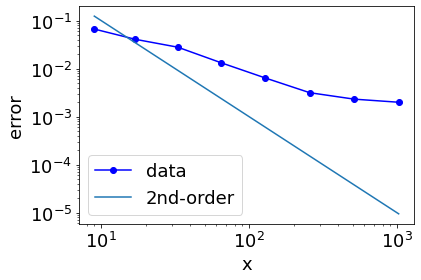

In [10]:
plt.loglog(resolutions, errs, 'bo-',label='data')

rf = np.array(resolutions,dtype=float)
plt.loglog(resolutions, 10*rf**(-2),label='2nd-order')
plt.legend()
plt.xlabel('x')
plt.ylabel('error')
plt.savefig('../advection_convergence_id_weno.png',bbox_inches='tight')

In [11]:
A = 0.25
K = 1
def soln(x, t, omega):
    return 0.5 + A*np.sin(2*np.pi*(K*x - omega*t))

In [12]:
errs = []
for nf in final_names:
    with h5py.File(nf,'r') as ff:
        x = ff['/VolumeLocations/x'][0]
        var = ff['c.c.mat.volume_fraction_0'][0].reshape(x.shape[0])
        err = var - soln(x, 1, 1)
        l2_err = integrate.romb(err*err, dx=(x[1]-x[0]))
        errs.append(np.sqrt(l2_err))
        #errs.append(np.max(np.abs(err)))

In [13]:
errs

[0.033251500426532604,
 0.020367249936972438,
 0.013942765130349049,
 0.006583147735065204,
 0.003183426161917454,
 0.0015757442256136677,
 0.0011571984867200136,
 0.00099749560389824]

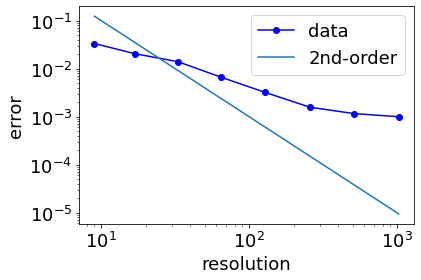

In [14]:
plt.loglog(resolutions, errs,'bo-',label='data')
plt.loglog(resolutions, 10*rf**(-2),label='2nd-order')
#plt.loglog(resolutions, 1*rf**(-1),label='first-order')
plt.xlabel('resolution')
plt.ylabel('error')
plt.legend()
plt.savefig('../advection_convergence_weno.png',bbox_inches='tight')

In [15]:
dxs = []
xs = []
errs = []
for nf in final_names:
    with h5py.File(nf,'r') as ff:
        x = ff['/VolumeLocations/x'][0,:]
        xs.append(x)
        dxs.append(x[1]-x[0])
        var = ff['c.c.mat.volume_fraction_0'][0].reshape(x.shape[0])
        err = var - soln(x, 1, 1)
        errs.append(err)

In [16]:
[err.shape for err in errs]

[(9,), (17,), (33,), (65,), (129,), (257,), (513,), (1025,)]

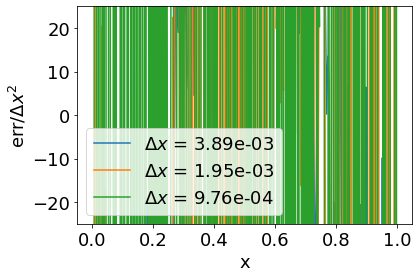

In [17]:
N=5
for dx,x,err in zip(dxs[N:],xs[N:],errs[N:]):
    plt.plot(x,err/(dx**2),label=r'$\Delta x$ = %.2e' % dx)
    plt.ylim(-25,25)
plt.xlabel('x')
plt.ylabel(r'err/$\Delta x^2$')
plt.legend()
plt.savefig('../advection_pointwise_convergence_weno.png',bbox_inches='tight')